In [14]:
# Instalar todas las librerías necesarias si no están ya en el entorno uv
# Ejecuta este bloque una sola vez
!uv pip install pandas matplotlib seaborn nltk wordcloud spacy scikit-learn nlpaug

# Descargar modelo de spaCy y datos de NLTK
!python -m spacy download en_core_web_sm

import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

Using Python 3.11.14 environment at: c:\Users\bruno\Desktop\proyectos\proyecto9\Project_9_NLP_Team2\.venv
Resolved 71 packages in 220ms
 Downloaded blis
 Downloaded thinc
 Downloaded nltk
 Downloaded spacy
Prepared 16 packages in 1.73s
Installed 16 packages in 1.10s
 + blis==1.3.3
 + catalogue==2.0.10
 + cloudpathlib==0.24.0
 + confection==1.3.3
 + cymem==2.0.13
 + murmurhash==1.0.15
 + nltk==3.9.4
 + preshed==3.0.13
 + smart-open==7.6.1
 + spacy==3.8.14
 + spacy-legacy==3.0.12
 + spacy-loggers==1.0.5
 + srsly==2.5.3
 + thinc==8.3.13
 + wasabi==1.1.3
 + weasel==1.0.0
Using Python 3.11.14 environment at: c:\Users\bruno\Desktop\proyectos\proyecto9\Project_9_NLP_Team2\.venv
Resolved 1 package in 2.14s
 Downloaded en-core-web-sm
Prepared 1 package in 1.14s
Installed 1 package in 19ms
 + en-core-web-sm==3.8.0 (from https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl)


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


ImportError: cannot import name '_regex' from partially initialized module 'regex' (most likely due to a circular import) (c:\Users\bruno\Desktop\proyectos\proyecto9\Project_9_NLP_Team2\.venv\Lib\site-packages\regex\__init__.py)

# 📓 Celda 1 – Carga del dataset e inspección básica

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv('../data/raw/youtoxic_english_1000.csv')

# Información general
print('Shape:', df.shape)
print('\nColumnas:', df.columns.tolist())
print('\nPrimeras filas:')
df.head()

Shape: (1000, 15)

Columnas: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

Primeras filas:


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,If only people would just take a step back and...,False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to app...,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' ba...,True,True,False,False,True,False,False,False,False,False,False,False
3,Ugg7Gd006w1MPngCoAEC,04kJtp6pVXI,There are a very large number of people who do...,False,False,False,False,False,False,False,False,False,False,False,False
4,Ugg8FfTbbNF8IngCoAEC,04kJtp6pVXI,"The Arab dude is absolutely right, he should h...",False,False,False,False,False,False,False,False,False,False,False,False


# 📊 Celda 2 – Valores nulos y distribución de la clase objetivo

Valores nulos por columna:
CommentId          0
VideoId            0
Text               0
IsToxic            0
IsAbusive          0
IsThreat           0
IsProvocative      0
IsObscene          0
IsHatespeech       0
IsRacist           0
IsNationalist      0
IsSexist           0
IsHomophobic       0
IsReligiousHate    0
IsRadicalism       0
dtype: int64


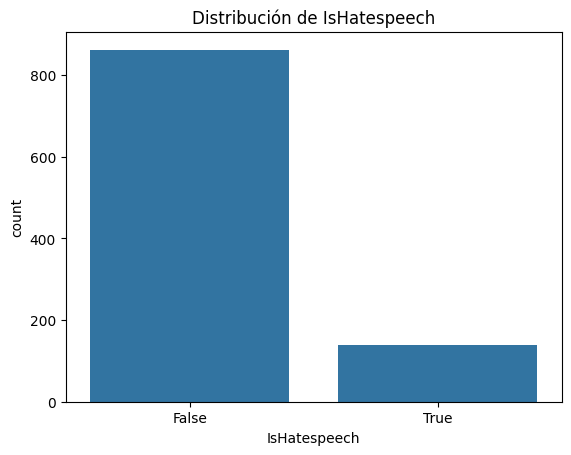

Conteo:
IsHatespeech
False    862
True     138
Name: count, dtype: int64

Proporción:
IsHatespeech
False    0.862
True     0.138
Name: proportion, dtype: float64


In [2]:
# Valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

# Distribución de IsHatespeech
sns.countplot(x='IsHatespeech', data=df)
plt.title('Distribución de IsHatespeech')
plt.show()

print('Conteo:')
print(df['IsHatespeech'].value_counts())
print('\nProporción:')
print(df['IsHatespeech'].value_counts(normalize=True))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...


       text_length   word_count
count  1000.000000  1000.000000
mean    185.554000    33.776000
std     270.780777    49.069498
min       3.000000     1.000000
25%      47.000000     9.000000
50%     101.000000    19.000000
75%     217.000000    39.000000
max    4421.000000   815.000000


[nltk_data]   Unzipping corpora\stopwords.zip.


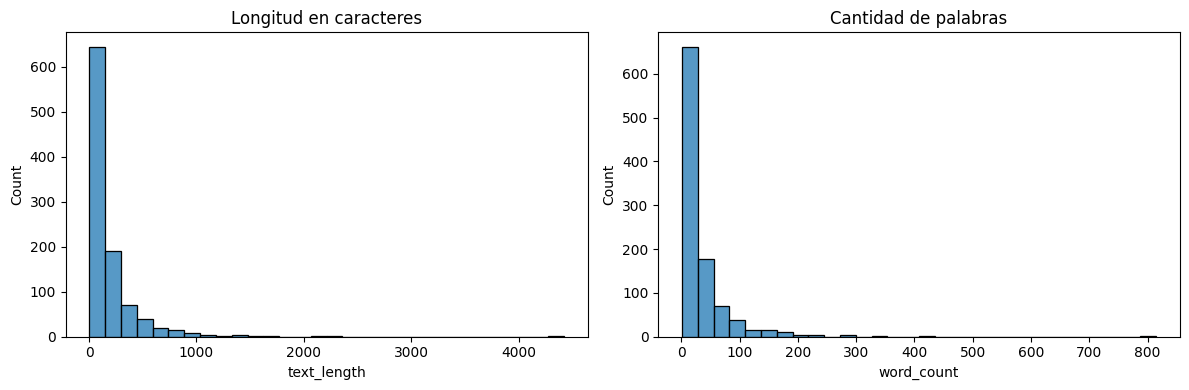

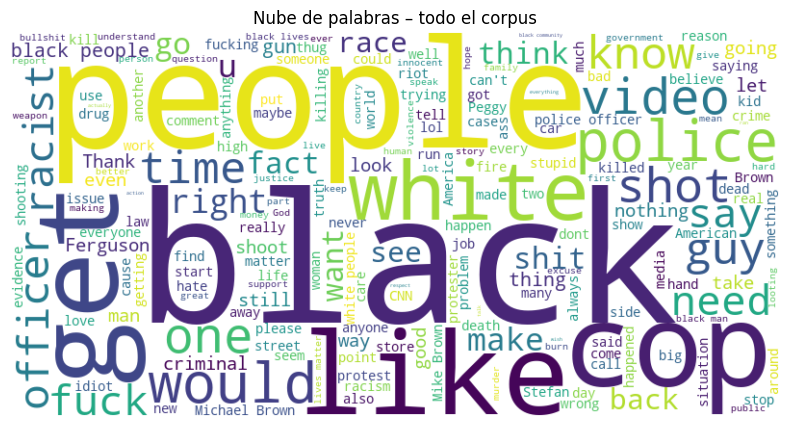

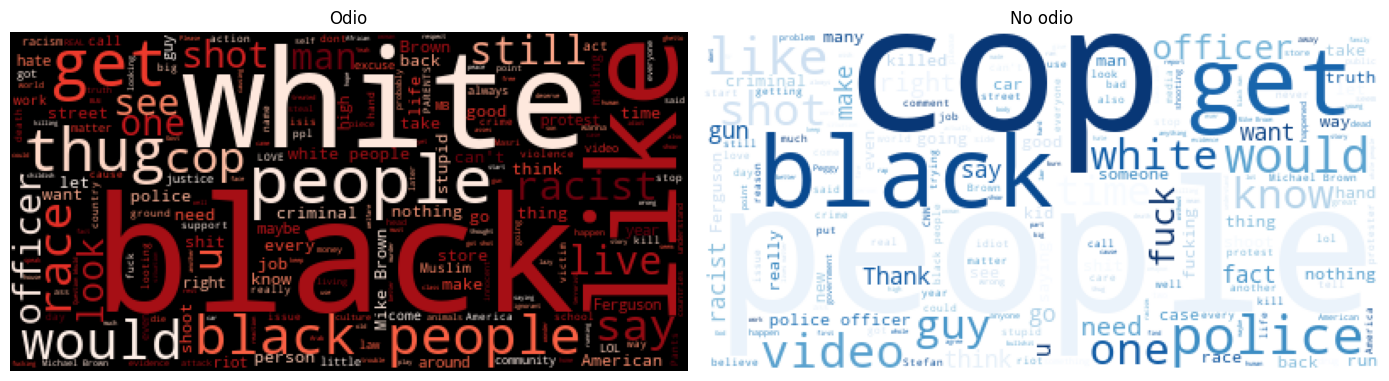

In [4]:
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud

# FIX: punkt_tab es necesario en NLTK >= 3.8
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

df['text_length'] = df['Text'].astype(str).apply(len)
df['word_count']  = df['Text'].astype(str).apply(lambda x: len(x.split()))

print(df[['text_length', 'word_count']].describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['text_length'], bins=30, ax=ax1)
ax1.set_title('Longitud en caracteres')
sns.histplot(df['word_count'], bins=30, ax=ax2)
ax2.set_title('Cantidad de palabras')
plt.tight_layout()
plt.show()

stop_words = set(stopwords.words('english'))
all_text   = ' '.join(df['Text'].dropna().astype(str))

wordcloud = WordCloud(stopwords=stop_words, background_color='white',
                      width=800, height=400).generate(all_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de palabras – todo el corpus')
plt.show()

hate_text   = ' '.join(df[df['IsHatespeech'] == True]['Text'].astype(str))
nohate_text = ' '.join(df[df['IsHatespeech'] == False]['Text'].astype(str))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.imshow(WordCloud(stopwords=stop_words, background_color='black',
                     colormap='Reds').generate(hate_text))
ax1.set_title('Odio')
ax1.axis('off')
ax2.imshow(WordCloud(stopwords=stop_words, background_color='white',
                     colormap='Blues').generate(nohate_text))
ax2.set_title('No odio')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [5]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print('Original:', df.loc[0, 'Text'])
print('Limpio  :', clean_text(df.loc[0, 'Text']))

df['clean_text'] = df['Text'].apply(clean_text)

# MEJORA: avisar si hay textos que quedaron vacíos tras la limpieza
empty_after_clean = (df['clean_text'] == '').sum()
print(f'\nTextos vacíos tras limpieza: {empty_after_clean}')

df[['Text', 'clean_text']].head()

Original: If only people would just take a step back and not make this case about them, because it wasn't about anyone except the two people in that situation.  To lump yourself into this mess and take matters into your own hands makes these kinds of protests selfish and without rational thought and investigation.  The guy in this video is heavily emotional and hyped up and wants to be heard, and when he gets heard he just presses more and more.  He was never out to have a reasonable discussion.  Kudos to the Smerconish for keeping level the whole time and letting Masri make himself out to be a fool.  How dare he and those that tore that city down in protest make this about themselves and to dishonor the entire incident with their own hate.  By the way, since when did police brutality become an epidemic?  I wish everyone would just stop pretending like they were there and they knew EXACTLY what was going on, because there's no measurable amount of people that honestly witnessed this in

,Text,clean_text
0,If only people would just take a step back and...,if only people would just take a step back and...
1,Law enforcement is not trained to shoot to app...,law enforcement is not trained to shoot to app...
2,\nDont you reckon them 'black lives matter' ba...,dont you reckon them black lives matter banner...
3,There are a very large number of people who do...,there are a very large number of people who do...
4,"The Arab dude is absolutely right, he should h...",the arab dude is absolutely right he should ha...


In [11]:
import spacy
from tqdm import tqdm

nlp = spacy.load('en_core_web_sm')

docs = nlp.pipe(df['clean_text'].tolist(), batch_size=50, n_process=1)
df['lemmatized_text'] = [
    ' '.join([token.lemma_ for token in doc
              if not token.is_stop and not token.is_punct and token.lemma_.strip()])
    for doc in tqdm(docs, total=len(df))
]

# MEJORA: avisar si hay textos vacíos tras lematizar
empty_after_lemma = (df['lemmatized_text'].str.strip() == '').sum()
print(f'Textos vacíos tras lematización: {empty_after_lemma}')

df[['clean_text', 'lemmatized_text']].head(10)

100%|██████████| 1000/1000 [00:07<00:00, 138.06it/s]

Textos vacíos tras lematización: 3


,clean_text,lemmatized_text
0,if only people would just take a step back and...,people step case not people situation lump mes...
1,law enforcement is not trained to shoot to app...,law enforcement train shoot apprehend train sh...
2,dont you reckon them black lives matter banner...,not reckon black life matter banner hold white...
3,there are a very large number of people who do...,large number people like police officer call c...
4,the arab dude is absolutely right he should ha...,arab dude absolutely right shoot extra time sh...
5,here people his facebook is he has ties with i...,people facebook tie isis terrorist group musli...
6,check out this you tube post black man goes on...,check tube post black man go epic rant ferguso...
7,i would love to see this pussy go to staten is...,love pussy staten island spit cop love happen ...
8,i agree with the protestor,agree protestor
9,mike browns father was made to say that boooshit,mike browns father boooshit


In [12]:
counts      = df['IsHatespeech'].value_counts()
proportions = df['IsHatespeech'].value_counts(normalize=True)

print('Distribución actual de IsHatespeech:')
print(counts)
print(proportions)

print('\nLongitud media de palabras (lematizadas) por clase:')
print(df.groupby('IsHatespeech')['lemmatized_text']
        .apply(lambda x: x.str.split().str.len().mean()))

# MEJORA: decisión automática en lugar de nota manual
AUGMENTATION_THRESHOLD = 0.25
minority_ratio = proportions.min()
APPLY_AUGMENTATION = minority_ratio < AUGMENTATION_THRESHOLD

print(f'\nRatio clase minoritaria: {minority_ratio:.2%}')
print(f'¿Aplicar augmentation? {"SÍ" if APPLY_AUGMENTATION else "NO"}')

Distribución actual de IsHatespeech:
IsHatespeech
False    862
True     138
Name: count, dtype: int64
IsHatespeech
False    0.862
True     0.138
Name: proportion, dtype: float64

Longitud media de palabras (lematizadas) por clase:
IsHatespeech
False    14.273782
True     22.173913
Name: lemmatized_text, dtype: float64

Ratio clase minoritaria: 13.80%
¿Aplicar augmentation? SÍ


In [15]:
if APPLY_AUGMENTATION:
    import nltk
    import nlpaug.augmenter.word as naw

    nltk.download('averaged_perceptron_tagger_eng')
    nltk.download('wordnet')
    nltk.download('omw-1.4')

    hate_mask  = df['IsHatespeech'] == True
    hate_texts = df.loc[hate_mask, 'clean_text'].values

    aug = naw.SynonymAug(aug_src='wordnet')

    # FIX: aug.augment() puede devolver lista vacía si el texto es muy corto
    # o ninguna palabra tiene sinónimo → fallback al texto original
    def safe_augment(text):
        result = aug.augment(text)
        if result and len(result) > 0:
            return result[0]
        return text  # fallback: devuelve el texto sin cambios

    augmented_texts = [safe_augment(t) for t in tqdm(hate_texts, desc='Augmenting')]

    df_aug = df.loc[hate_mask].copy().reset_index(drop=True)
    df_aug['Text']       = augmented_texts
    df_aug['clean_text'] = augmented_texts

    new_docs = nlp.pipe(df_aug['clean_text'].tolist(), batch_size=10)
    df_aug['lemmatized_text'] = [
        ' '.join([token.lemma_ for token in doc
                  if not token.is_stop and not token.is_punct and token.lemma_.strip()])
        for doc in new_docs
    ]

    df = pd.concat([df, df_aug], ignore_index=True)

    print('Nuevo tamaño:', df.shape)
    print(df['IsHatespeech'].value_counts())
else:
    print('Augmentation omitido: el balance es aceptable.')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\bruno\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Augmenting: 100%|██████████| 138/138 [00:00<00:00, 723.94it/s]


Nuevo tamaño: (1138, 19)
IsHatespeech
False    862
True     276
Name: count, dtype: int64


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib

# MEJORA: filtrar filas con lemmatized_text vacío antes de vectorizar
mask_valid = df['lemmatized_text'].str.strip() != ''
df_clean   = df[mask_valid].reset_index(drop=True)
print(f'Filas eliminadas por texto vacío: {(~mask_valid).sum()}')

y      = df_clean['IsHatespeech'].astype(int)
corpus = df_clean['lemmatized_text']

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X = vectorizer.fit_transform(corpus)
print('Dimensiones TF-IDF:', X.shape)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, stratify=y_temp, random_state=42)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')

joblib.dump(vectorizer, 'vectorizer.pkl')
joblib.dump((X_train, y_train, X_val, y_val, X_test, y_test), 'train_val_test_sets.pkl')
print('Artefactos guardados.')

Filas eliminadas por texto vacío: 4
Dimensiones TF-IDF: (1134, 4442)
Train: 793  Val: 170  Test: 171
Artefactos guardados.
